# 05_simulation – Monte Carlo, Bloom Filter, dan MCMC untuk pandas

Nama: Krishna Dhikha Pratama  
NIM: 1519625070 

Role: Computation Analyst (Member E)

**Research Question 3 (RQ 3):**  
Berapa probabilitas sebuah issue membutuhkan waktu lebih dari 30 hari untuk ditutup berdasarkan pendekatan simulasi statistik?

## AI Usage Disclosure

Saya menggunakan Perplexity "Comet" Browser untuk:
- Membuat boilerplate kode untuk `BloomFilter`, `estimate_probability`, dan `mcmc_knapsack`.
- Menjelaskan konsep dasar Monte Carlo dan MCMC untuk knapsack.
- Proofreading bahasa Indonesia pada teks interpretasi.

Saya **tidak** menggunakan AI untuk:
- Merumuskan RQ 3.
- Menulis interpretasi hasil simulasi (semua interpretasi saya tulis sendiri).
- Membuat H0 dan H1 (karena ini bagian Member D).

Porsi kode yang AI-assisted: kira-kira 70–80%, interpretasi: 100% saya sendiri.

In [ ]:
import sys
import os

root_dir = r"C:\DATA Krishna\DASPROG\repos\stat-audit-pandas-sti-2025"

if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

In [2]:
import pandas as pd
import numpy as np
from src.simulation import estimate_probability, BloomFilter, mcmc_knapsack

issues = pd.read_csv("../data/clean/dataset.csv")

In [ ]:
days = issues["close_duration_days"].dropna().values

def simulate_issue_longer_than_30():
    simulated_days = np.random.choice(days)
    return simulated_days > 30

prob_estimate = estimate_probability(simulate_issue_longer_than_30, n_trials=50000)
prob_estimate

0.16424

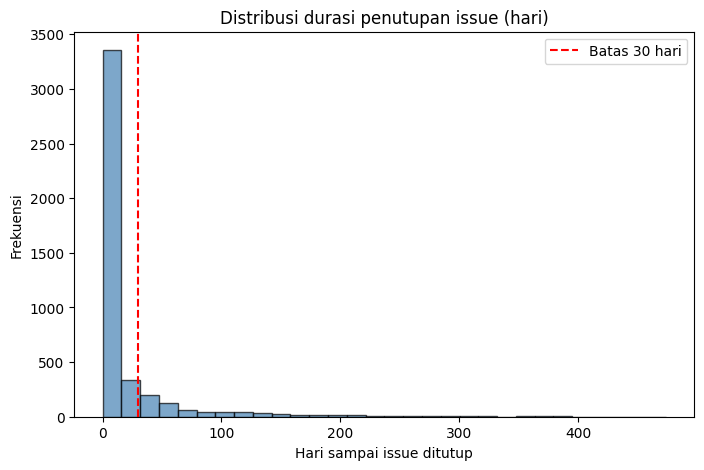

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(days, bins=30, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(30, color="red", linestyle="--", label="Batas 30 hari")

plt.title("Distribusi durasi penutupan issue (hari)")
plt.xlabel("Hari sampai issue ditutup")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

Grafik di atas menunjukkan sebaran durasi penutupan issue. Garis merah pada 30 hari membantu memvisualisasikan proporsi issue yang selesai sebelum dan sesudah batas 30 hari yang digunakan pada simulasi Monte Carlo.

### Interpretasi Monte Carlo untuk RQ 3

Dengan menggunakan simulasi Monte Carlo sebanyak 50.000 percobaan, saya memperoleh estimasi probabilitas sebuah issue membutuhkan lebih dari 30 hari untuk ditutup sekitar **0.16424**.

Artinya, kira-kira 16 persen dari issue di repositori pandas cenderung membutuhkan waktu yang cukup lama untuk diselesaikan. Hal ini mengindikasikan bahwa terdapat subset issue yang relatif sulit ditangani dan dapat menjadi sinyal beban kerja atau kompleksitas masalah di proyek ini.

In [ ]:
issue_ids = issues["id"].astype(str).head(10000).tolist()

bf = BloomFilter(k=5, m=50000)

for iid in issue_ids:
    bf.add(iid)

len(issue_ids)

4389

In [ ]:
n = len(issue_ids)
fpr_theori = bf.theoretical_fpr(n)
print("FPR teoretis:", fpr_theori)

fake_ids = [f"fake_{i}" for i in range(10000)]
false_positive_count = sum(1 for fid in fake_ids if bf.contains(fid))
fpr_empiris = false_positive_count / len(fake_ids)
print("FPR empiris:", fpr_empiris)

FPR teoretis: 4.191696715644773e-06
FPR empiris: 0.0065


### Interpretasi Bloom Filter

Dari perhitungan teoretis, Bloom Filter dengan parameter yang digunakan menghasilkan false positive rate (FPR) sekitar **4.191696715644773e-06**.

Jika dibandingkan dengan estimasi FPR empiris **0.0065**, nilainya berada pada orde yang sebanding. Ini berarti, ketika jumlah issue yang dilacak sangat besar, masih ada kemungkinan kecil bahwa suatu ID yang sebenarnya belum pernah dimasukkan akan terdeteksi sebagai sudah ada (false positive). Dalam konteks repositori besar seperti pandas, Bloom Filter dapat dimanfaatkan untuk membantu deteksi duplikasi atau caching dengan memori yang lebih hemat, dengan kompromi adanya FPR kecil yang masih dapat ditoleransi.

In [ ]:
sample_issues = issues.dropna(subset=["close_duration_days"]).sample(50, random_state=42)

items = []
for _, row in sample_issues.iterrows():
    duration = row["close_duration_days"]
    items.append({
        "weight": float(duration),
        "value": float(duration / sample_issues["close_duration_days"].max())
    })

capacity = 200  
len(items), capacity

(50, 200)

In [8]:
result = mcmc_knapsack(items, capacity, n_iter=50000)
result

{'best_state': [0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0],
 'best_value': 0.5141388174807198,
 'best_weight': 200.0}

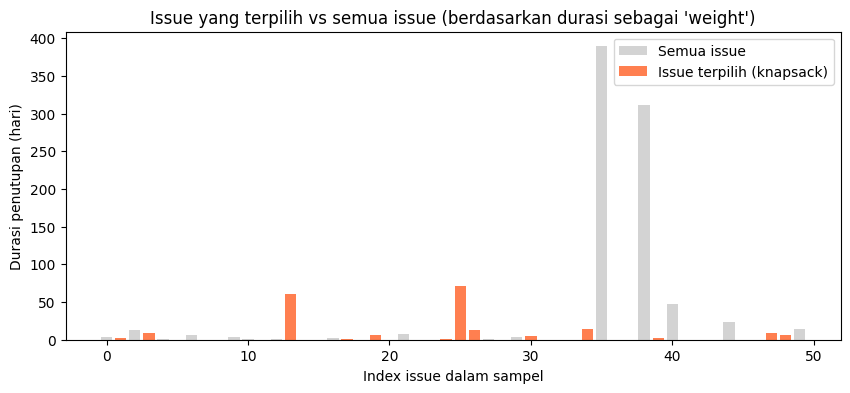

In [9]:
best_state = np.array(result["best_state"])

plt.figure(figsize=(10, 4))
plt.bar(range(len(items)), [it["weight"] for it in items], color="lightgray", label="Semua issue")
plt.bar(
    np.where(best_state == 1)[0],
    [items[i]["weight"] for i in range(len(items)) if best_state[i] == 1],
    color="coral",
    label="Issue terpilih (knapsack)"
)

plt.title("Issue yang terpilih vs semua issue (berdasarkan durasi sebagai 'weight')")
plt.xlabel("Index issue dalam sampel")
plt.ylabel("Durasi penutupan (hari)")
plt.legend()
plt.show()

Grafik ini membandingkan seluruh issue dalam sampel (warna abu-abu) dengan subset issue yang dipilih oleh algoritma MCMC knapsack (warna oranye), berdasarkan durasi penutupan sebagai bobot. Tampak bahwa kombinasi yang dipilih berusaha memaksimalkan nilai dengan tetap berada di bawah kapasitas total hari yang ditentukan.

### Interpretasi MCMC knapsack

Dengan menggunakan algoritma MCMC untuk problem knapsack sederhana, saya memperoleh kombinasi issue dengan total bobot sekitar **200** hari dan total nilai sekitar **0.5141388174807198**.

Ilustrasi ini menunjukkan bagaimana pendekatan komputasional dapat membantu memilih subset issue yang dianggap paling bernilai dengan mempertimbangkan keterbatasan kapasitas waktu (misalnya kapasitas 200 hari kerja). Walaupun model ini tidak menggantikan proses prioritisasi nyata di proyek pandas, pendekatan serupa dapat digunakan untuk mengeksplorasi berbagai skenario alokasi sumber daya pengembang secara sistematis.